In [12]:
from cobra.io import read_sbml_model
from cobra import Reaction, Metabolite
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

model = read_sbml_model('eps_ecoli_model_lb.xml')
BIOMASS_RXN = 'BIOMASS_Ec_iML1515_core_75p37M'
print(model)

iML1515


## Adding gene associations for bcsA and pgaB

Two of the three EPS pathways (cellulose via `CELSYNTH`, PNAG via `PUACGAMS`/`PUACGAMtr`/`PUACGAMex`) were added manually earlier in this project without gene-reaction associations, so their defining genes couldn't be knocked out with cobra's gene-deletion tools. This section fixes both, using locus tags confirmed against BioCyc/EcoCyc:

- **bcsA = b3533** (cellulose synthase catalytic subunit, synonyms yhjO/yhjP) -- added directly as the gene rule for `CELSYNTH`, since bcsA *is* the enzyme that reaction represents.
- **pgaB = b1023** (PNAG periplasmic partial N-deacetylase) -- added as a new reaction, `PUACGAMDEAC`, inserted between the existing `PUACGAMtr` (transport to periplasm) and `PUACGAMex` (export) steps. Biologically, PgaB partially deacetylates nascent PNAG in the periplasm, which is required for the polymer to be retained in the biofilm matrix; here it's modeled as an obligate step consuming one water and releasing one acetate per polymer unit before export. This is a simplified, lumped representation (consistent with how `CELSYNTH`/`COLASYNTH` already treat these EPS polymers as single lumped species rather than tracking exact degree of polymerization/acetylation), not literal per-residue acetylation chemistry.

In [13]:
# bcsA (b3533) -- cellulose synthase catalytic subunit
model.reactions.CELSYNTH.gene_reaction_rule = 'b3533'
model.genes.get_by_id('b3533').name = 'bcsA'
print("CELSYNTH gene rule:", model.reactions.CELSYNTH.gene_reaction_rule)

CELSYNTH gene rule: b3533


In [14]:
# pgaB (b1023) -- PNAG partial N-deacetylase, required for export
puacgamdeac_p = Metabolite('puacgamdeac_p', formula='C6H12NO4R',
    name='Partially deacetylated poly-beta-1,6-N-acetyl-D-glucosamine', compartment='p')

pgaB_rxn = Reaction('PUACGAMDEAC')
pgaB_rxn.name = 'PNAG partial N-deacetylation (PgaB)'
pgaB_rxn.lower_bound = 0.0
pgaB_rxn.upper_bound = 1000.0
pgaB_rxn.add_metabolites({
    model.metabolites.puacgam_p: -1,
    model.metabolites.h2o_p: -1,
    puacgamdeac_p: 1,
    model.metabolites.ac_p: 1,
})
pgaB_rxn.gene_reaction_rule = 'b1023'
model.add_reactions([pgaB_rxn])
model.genes.get_by_id('b1023').name = 'pgaB'

# Rewire PUACGAMex to consume the deacetylated form instead of raw puacgam_p
model.reactions.PUACGAMex.subtract_metabolites({model.metabolites.puacgam_p: -1})
model.reactions.PUACGAMex.add_metabolites({puacgamdeac_p: -1})

print("PUACGAMDEAC:", pgaB_rxn.reaction, "| genes:", pgaB_rxn.gene_reaction_rule)
print("PUACGAMex now:", model.reactions.PUACGAMex.reaction)

PUACGAMDEAC: h2o_p + puacgam_p --> ac_p + puacgamdeac_p | genes: b1023
PUACGAMex now: puacgamdeac_p --> puacgam_e


In [15]:
# Sanity check: model still solves, and both new gene associations behave correctly
sol = model.optimize()
print(f"Growth rate after additions: {sol.objective_value:.4f} 1/h")

with model:
    model.genes.get_by_id('b3533').knock_out()
    model.objective = 'EX_cellulose_e'
    print(f"Cellulose capacity, bcsA knocked out: {model.slim_optimize():.4f}")
with model:
    model.objective = 'EX_cellulose_e'
    print(f"Cellulose capacity, wild-type:        {model.slim_optimize():.4f}")

with model:
    model.genes.get_by_id('b1023').knock_out()
    model.objective = 'EX_puacgam_e'
    print(f"PNAG capacity, pgaB knocked out:       {model.slim_optimize():.4f}")
with model:
    model.objective = 'EX_puacgam_e'
    print(f"PNAG capacity, wild-type:              {model.slim_optimize():.4f}")

Growth rate after additions: 1.9527 1/h
Cellulose capacity, bcsA knocked out: 0.0000
Cellulose capacity, wild-type:        18.3467
PNAG capacity, pgaB knocked out:       0.0000
PNAG capacity, wild-type:              16.5929


## Basic model stats (with bcsA + pgaB additions)

In [16]:
model.objective = BIOMASS_RXN
baseline_growth = model.slim_optimize()

print("\n=== Model size ===")
print(f"Reactions:   {len(model.reactions)}")
print(f"Metabolites: {len(model.metabolites)}")
print(f"Genes:       {len(model.genes)}")

print("\n=== Objective ===")
print(f"Biomass reaction: {BIOMASS_RXN}")
print(f"Expression: {model.objective.expression}")
print(f"Max growth rate (wild-type, LB medium): {baseline_growth:.4f} 1/h")

print("\n=== EPS pathway exchange reactions (independent max capacity) ===")
eps_rxns = {'Cellulose': 'EX_cellulose_e', 'Colanic acid': 'EX_colacid_e', 'PNAG': 'EX_puacgam_e'}
for label, rxn_id in eps_rxns.items():
    with model:
        model.objective = rxn_id
        flux = model.slim_optimize()
    print(f"  {label:15s} ({rxn_id}): max capacity = {flux:.4f} mmol/gDW/h")


=== Model size ===
Reactions:   2721
Metabolites: 1883
Genes:       1518

=== Objective ===
Biomass reaction: BIOMASS_Ec_iML1515_core_75p37M
Expression: 1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Max growth rate (wild-type, LB medium): 1.9527 1/h

=== EPS pathway exchange reactions (independent max capacity) ===
  Cellulose       (EX_cellulose_e): max capacity = 18.3467 mmol/gDW/h
  Colanic acid    (EX_colacid_e): max capacity = 3.8691 mmol/gDW/h
  PNAG            (EX_puacgam_e): max capacity = 16.5929 mmol/gDW/h


In [17]:
# Genes going into the knockout screen below, with their mapped role
ko_genes = {
    'wcaJ':  ('b2047', 'Colanic acid (feeds UDPGPT -> COLASYNTH)'),
    'cpsG':  ('b2048', 'Colanic acid (GDP-mannose precursor branch)'),
    'yahA':  ('b0315', 'c-di-GMP degradation (1 of 5 CDGUNPD isozymes)'),
    'yhjH':  ('b3525', 'c-di-GMP degradation (1 of 5 CDGUNPD isozymes)'),
    'gmr':   ('b1285', 'c-di-GMP degradation (1 of 5 CDGUNPD isozymes)'),
    'ydaM':  ('b1341', 'c-di-GMP synthesis (1 of 5 DGUNC isozymes)'),
    'bcsA':  ('b3533', 'Cellulose synthase (sole gene on CELSYNTH -- added this session)'),
    'pgaB':  ('b1023', 'PNAG partial deacetylation (sole gene on PUACGAMDEAC -- added this session)'),
}
gene_summary = pd.DataFrame([
    {'gene': g, 'locus_tag': tag, 'role': role, 'in_model': model.genes.has_id(tag)}
    for g, (tag, role) in ko_genes.items()
])
gene_summary

,gene,locus_tag,role,in_model
0,wcaJ,b2047,Colanic acid (feeds UDPGPT -> COLASYNTH),True
1,cpsG,b2048,Colanic acid (GDP-mannose precursor branch),True
2,yahA,b0315,c-di-GMP degradation (1 of 5 CDGUNPD isozymes),True
3,yhjH,b3525,c-di-GMP degradation (1 of 5 CDGUNPD isozymes),True
4,gmr,b1285,c-di-GMP degradation (1 of 5 CDGUNPD isozymes),True
5,ydaM,b1341,c-di-GMP synthesis (1 of 5 DGUNC isozymes),True
6,bcsA,b3533,Cellulose synthase (sole gene on CELSYNTH -- a...,True
7,pgaB,b1023,PNAG partial deacetylation (sole gene on PUACG...,True


## Single-gene knockout screen

For each gene above, knock it out individually and measure growth rate plus each EPS pathway's max capacity under a 90%-growth floor (same two-stage logic used throughout this project -- see the `combined_EPS` condition in `eps_analysis.ipynb`). Genes that are 1-of-5 redundant isozymes (yahA, yhjH, gmr, ydaM) are expected to show little to no single-knockout effect, since the other isozymes cover for them -- included anyway as an honest negative control, not just the "obvious winners" (bcsA, pgaB, wcaJ, cpsG).

In [18]:
def two_stage_eps(model, floor_fraction=0.9):
    model.objective = BIOMASS_RXN
    mu = model.slim_optimize()
    if mu is None or mu < 1e-9:
        return mu, {label: 0.0 for label in eps_rxns}
    with model:
        model.reactions.get_by_id(BIOMASS_RXN).lower_bound = floor_fraction * mu
        fluxes = {}
        for label, rxn_id in eps_rxns.items():
            model.objective = rxn_id
            fluxes[label] = model.slim_optimize()
    return mu, fluxes

results = []
wt_mu, wt_fluxes = two_stage_eps(model)
results.append({'gene': 'WT', 'locus_tag': '-', 'growth': wt_mu, **wt_fluxes})

for gene, (tag, role) in ko_genes.items():
    with model:
        model.genes.get_by_id(tag).knock_out()
        mu, fluxes = two_stage_eps(model)
    results.append({'gene': gene, 'locus_tag': tag, 'growth': mu, **fluxes})

ko_df = pd.DataFrame(results)
ko_df

,gene,locus_tag,growth,Cellulose,Colanic acid,PNAG
0,WT,-,1.95271,2.184252,0.475886,1.928556
1,wcaJ,b2047,1.95271,2.184252,0.000000,1.928556
2,cpsG,b2048,1.95271,2.184252,0.000000,1.928556
3,yahA,b0315,1.95271,2.184252,0.475886,1.928556
4,yhjH,b3525,1.95271,2.184252,0.475886,1.928556
5,gmr,b1285,1.95271,2.184252,0.475886,1.928556
6,ydaM,b1341,1.95271,2.184252,0.475886,1.928556
7,bcsA,b3533,1.95271,0.000000,0.475886,1.928556
8,pgaB,b1023,1.95271,2.184252,0.475886,0.000000


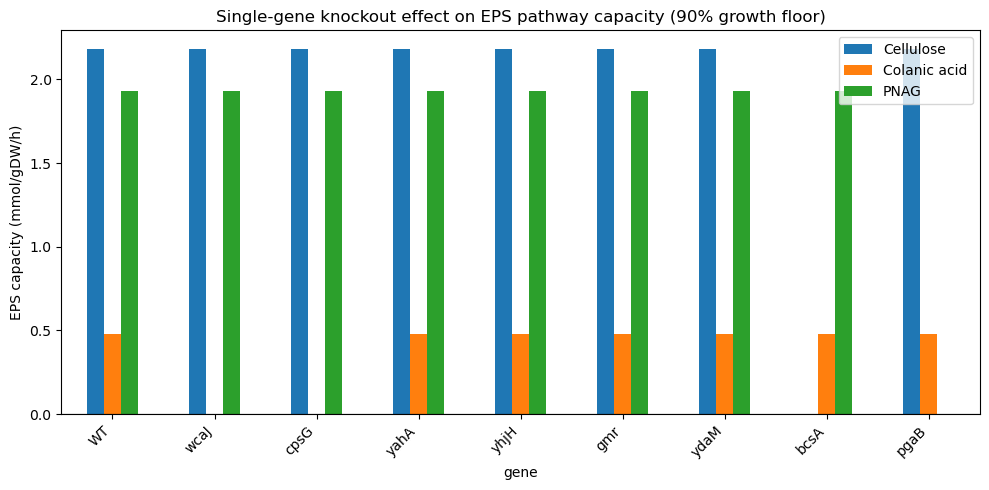

Saved: eps_knockout_screen.csv, eps_knockout_screen.png


In [19]:
ko_df.to_csv('eps_knockout_screen.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = ko_df.set_index('gene')[['Cellulose', 'Colanic acid', 'PNAG']]
plot_df.plot(kind='bar', ax=ax)
ax.set_ylabel('EPS capacity (mmol/gDW/h)')
ax.set_title('Single-gene knockout effect on EPS pathway capacity (90% growth floor)')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eps_knockout_screen.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: eps_knockout_screen.csv, eps_knockout_screen.png")